In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv("run_results.csv")

In [37]:
df.describe()

,d_model,model_depth,head_dimension,n_heads,d_ffn,vocab_size,n_params_embedding,n_params_encoder,n_params_decoder,n_params_mha,...,embedding_matrix_lr,attention_weight_matrix_lr,attention_bias_lr,w_ffn_in_lr,w_ffn_out_lr,bias_lr,unembedding_matrix_lr,final_loss,best_loss,training_wall_time
count,201.0,201.0,201.0,201.0,201.0,201.0,201.0,201.0,201.0,201.0,...,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.053972,0.000422,0.053972,0.000422,0.000105,0.053972,0.000422,19.664252,14.203675,7122.455705
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.076783,0.000600,0.076783,0.000600,0.000150,0.076783,0.000600,62.816994,57.226632,6575.177850
min,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.000977,0.000008,0.000977,0.000008,0.000002,0.000977,0.000008,3.830315,3.830315,486.828972
25%,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.003349,0.000026,0.003349,0.000026,0.000007,0.003349,0.000026,3.944498,3.944498,600.360922
50%,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.011482,0.000090,0.011482,0.000090,0.000022,0.011482,0.000090,4.740610,4.686128,707.087349
75%,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.072908,0.000570,0.072908,0.000570,0.000142,0.072908,0.000570,7.162799,5.325864,13846.235856
max,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.250000,0.001953,0.250000,0.001953,0.000488,0.250000,0.001953,374.245812,374.018747,13982.920307


In [38]:
print(df.columns)

Index(['d_model', 'model_depth', 'head_dimension', 'n_heads', 'd_ffn',
       'vocab_size', 'n_params_embedding', 'n_params_encoder',
       'n_params_decoder', 'n_params_mha', 'n_params_rms_norm', 'n_params_ffn',
       'n_params_transformer_block', 'n_parameters', 'base_lr', 'init_stddev',
       'absolute_init_stddev', 'max_lr', 'lr_schedule_name', 'optim_name',
       'optim_beta1', 'optim_beta2', 'optim_eps', 'weight_decay',
       'n_training_tokens', 'tokens_per_global_batch', 'batch_size',
       'sequence_len', 'n_pretrain_steps', 'n_warmup_steps',
       'embedding_matrix_lr', 'attention_weight_matrix_lr',
       'attention_bias_lr', 'w_ffn_in_lr', 'w_ffn_out_lr', 'bias_lr',
       'unembedding_matrix_lr', 'run_id', 'run_folder_path',
       'run_losses_df_path', 'final_loss', 'best_loss', 'training_wall_time'],
      dtype='object')


In [39]:
print(df['n_pretrain_steps'].unique())
print(df['n_parameters'].unique())

[89208.  3591.]
[11766784]


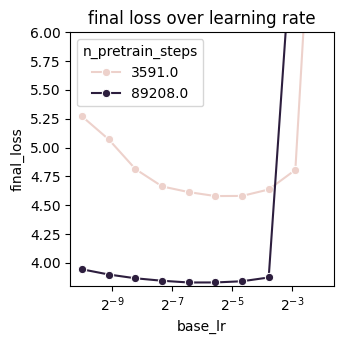

In [40]:
df_min_final_losses = df.groupby(['n_pretrain_steps', 'base_lr'])['final_loss'].min().reset_index()
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

# final loss
sns.lineplot(df_min_final_losses,
    x="base_lr",
    y="final_loss",
    hue='n_pretrain_steps',
    ax=ax,
    marker='o',
    )



ax.set_ylim(3.8, 6)

ax.set_xscale("log", base=2)
ax.set_title("final loss over learning rate")

plt.tight_layout()
plt.show()

[5.85204620e-02 1.08365232e-01 2.00665256e-01 3.71581772e-01
 6.88076332e-01 1.27414495e+00 2.35939718e+00 4.36901237e+00
 8.09031615e+00 1.49812383e+01 2.91676839e-01 5.40112419e-01
 1.00015286e+00 1.85203248e+00 3.42950009e+00 6.35057481e+00
 1.17596733e+01 2.17759682e+01 4.03236366e+01 7.46692708e+01]


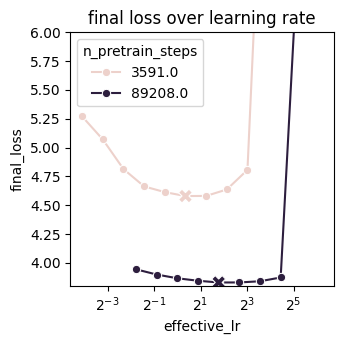

In [50]:
# factor = np.sqrt(89208/3591)
df_min_final_losses = df.groupby(['n_pretrain_steps', 'base_lr'])['final_loss'].min().reset_index()

# calculate the effective learning rate
df_min_final_losses['effective_lr'] = df_min_final_losses['base_lr'] * np.sqrt(df_min_final_losses['n_pretrain_steps'])

# find the best absolute performance for each pretrain step group
idx_best = df_min_final_losses.groupby('n_pretrain_steps')['final_loss'].idxmin()
df_best_per_step = df_min_final_losses.loc[idx_best]


print(df_min_final_losses['effective_lr'].unique())
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

# final loss
sns.lineplot(df_min_final_losses,
    x="effective_lr",
    y="final_loss",
    hue='n_pretrain_steps',
    ax=ax,
    marker='o',
    zorder=1,
    )

sns.scatterplot(
    df_best_per_step,
    x='effective_lr',
    y='final_loss',
    hue='n_pretrain_steps',
    ax=ax,
    marker='X',
    s=100,
    legend=False,
    zorder=2,
)



ax.set_ylim(3.8, 6)
# ax.set_xlim(2**(-16), 2**(-2))

ax.set_xscale("log", base=2)
ax.set_title("final loss over learning rate")

plt.tight_layout()
plt.show()

[5.85204620e-02 1.08365232e-01 2.00665256e-01 3.71581772e-01
 6.88076332e-01 1.27414495e+00 2.35939718e+00 4.36901237e+00
 8.09031615e+00 1.49812383e+01 2.91676839e-01 5.40112419e-01
 1.00015286e+00 1.85203248e+00 3.42950009e+00 6.35057481e+00
 1.17596733e+01 2.17759682e+01 4.03236366e+01 7.46692708e+01]


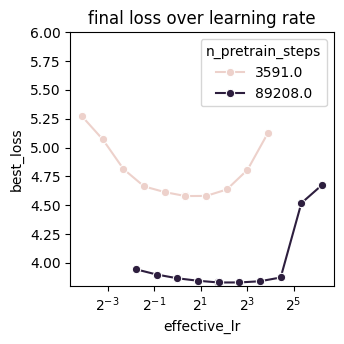

In [46]:
# factor = np.sqrt(89208/3591)
df_min_final_losses = df.groupby(['n_pretrain_steps', 'base_lr'])['best_loss'].min().reset_index()

# calculate the effective learning rate
df_min_final_losses['effective_lr'] = df_min_final_losses['base_lr'] * np.sqrt(df_min_final_losses['n_pretrain_steps'])

# find the best absolute performance for each pretrain step group
idx_best = df_min_final_losses.groupby('n_pretrain_steps')['best_loss'].idxmin()
df_best_per_step = df_min_final_losses.loc[idx_best]


print(df_min_final_losses['effective_lr'].unique())
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

# final loss
sns.lineplot(df_min_final_losses,
    x="effective_lr",
    y="best_loss",
    hue='n_pretrain_steps',
    ax=ax,
    marker='o',
    )

sns.scatterplot(
    df_best_per_step,
    x='effective_lr',
    y='best_loss',
    hue='n_pretrain_steps',
    ax=ax,
    marker='X',
    legend=False,
)



ax.set_ylim(3.8, 6)
# ax.set_xlim(2**(-16), 2**(-2))

ax.set_xscale("log", base=2)
ax.set_title("final loss over learning rate")

plt.tight_layout()
plt.show()

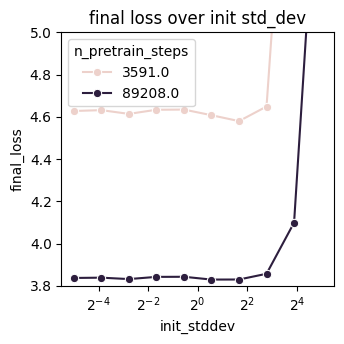

In [53]:
df_min_final_losses = df.groupby(['n_pretrain_steps', 'init_stddev'])['final_loss'].min().reset_index()
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

# final loss
sns.lineplot(df_min_final_losses,
    x="init_stddev",
    y="final_loss",
    hue='n_pretrain_steps',
    ax=ax,
    marker='o',
    )



ax.set_ylim(3.8, 5)
ax.set_xscale("log", base=2)

ax.set_title("final loss over init std_dev")

plt.tight_layout()
plt.show()

Get more statistics for next runs

In [70]:
idx_best = df.groupby(['n_pretrain_steps', 'init_stddev'])['final_loss'].idxmin()

df_best_lr = df.loc[idx_best, ['n_pretrain_steps', 'init_stddev', 'base_lr', 'final_loss']]
print(df_best_lr.groupby('n_pretrain_steps')['base_lr'].value_counts())

n_pretrain_steps  base_lr 
3591.0            0.021262    6
                  0.039373    4
89208.0           0.021262    7
                  0.011482    2
                  0.006201    1
Name: count, dtype: int64


In [72]:
idx_best = df.groupby(['n_pretrain_steps', 'base_lr'])['final_loss'].idxmin()

df_best_init = df.loc[idx_best, ['n_pretrain_steps', 'init_stddev', 'base_lr', 'final_loss']]
print(df_best_init.groupby('n_pretrain_steps')['init_stddev'].value_counts())

n_pretrain_steps  init_stddev
3591.0            3.174802       5
                  0.680395       2
                  1.469734       2
                  14.813995      1
89208.0           1.469734       6
                  3.174802       2
                  0.145816       1
                  14.813995      1
Name: count, dtype: int64


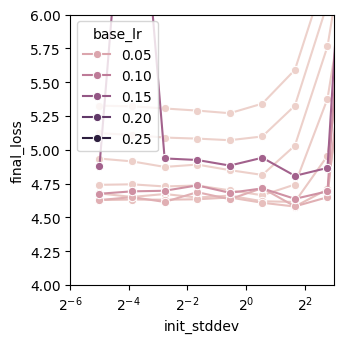

[3.12500000e-02 6.75037337e-02 1.45816130e-01 3.14980262e-01
 6.80395000e-01 1.46973449e+00 3.17480210e+00 6.85795186e+00
 1.48139954e+01 3.20000000e+01]


In [84]:
df_short_run = df[df['n_pretrain_steps'] == 3591]

fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

sns.lineplot(df_short_run,
    x='init_stddev',
    y='final_loss',
    hue='base_lr',
    ax=ax,
    marker='o',
    zorder=1,
)

ax.set_ylim(4, 6)
ax.set_xlim(2**-6, 2**3)
ax.set_xscale('log', base=2)

plt.tight_layout()
plt.show()
print(np.sort(df_short_run['init_stddev'].unique()))

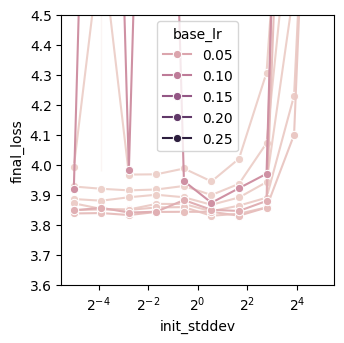

[3.12500000e-02 6.75037337e-02 1.45816130e-01 3.14980262e-01
 6.80395000e-01 1.46973449e+00 3.17480210e+00 6.85795186e+00
 1.48139954e+01 3.20000000e+01]


In [92]:
df_short_run = df[df['n_pretrain_steps'] != 3591]

fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

sns.lineplot(df_short_run,
    x='init_stddev',
    y='final_loss',
    hue='base_lr',
    ax=ax,
    marker='o',
    zorder=1,
)

ax.set_ylim(3.6, 4.5)
# ax.set_xlim(2**-6, 2**3)
ax.set_xscale('log', base=2)

plt.tight_layout()
plt.show()
print(np.sort(df_short_run['init_stddev'].unique()))